# Mô-đun 6: Xếp hạng Hành động Tăng Lương bằng Causal Inference

**Đồ án:** Hệ hỗ trợ quyết định trong định giá lương và tư vấn đàm phán lương  
**Module:** Action Ranking via Causal Forest (Heterogeneous Treatment Effects)  
**Phương pháp:** Generalized Random Forest — Causal Forest (Wager & Athey, 2018)

---

## Vị trí trong hệ thống DSS

```
Module 1 (Salary Valuation)  ──┐
Module 2 (Peer Benchmark)    ──┤
Module 3 (Offer Assessment)  ──┤──→ Module 5 (What-if / Recourse)
Module 4 (Negotiation Optim) ──┘         ↓
                                   Module 6 (Causal Action Ranking)
                                         ↓
                                   Module 7 (Chatbot Explanation)
```

**Module 6 trả lời:** *"Trong các hành động có thể thực hiện, hành động nào mang lại  
tác động nhân quả lớn nhất đến mức lương — tính riêng cho từng ứng viên?"*

---

## Mục tiêu học thuật

1. Ước lượng **Conditional Average Treatment Effect (CATE)** của 5 hành động tăng lương.
2. Sử dụng **Causal Forest** (GRF) để xử lý **heterogeneous treatment effects**.
3. Cung cấp khoảng tin cậy (confidence interval) cho từng ước lượng.
4. Xếp hạng hành động theo **điểm tổng hợp** gồm: tác động × khả thi / chi phí.
5. Diễn giải kết quả bằng ngôn ngữ phù hợp với dữ liệu quan sát (không khẳng định nhân quả tuyệt đối).


## 1. Nền tảng lý thuyết

### 1.1 Tại sao không dùng Feature Importance để kết luận nhân quả?

**Feature importance** (từ Random Forest, XGBoost, SHAP...) đo mức độ **tương quan**
giữa một feature và biến mục tiêu — **không phải quan hệ nhân quả**.

Ví dụ minh họa: `certifications` có thể có feature importance cao vì người có nhiều
chứng chỉ thường làm ở công ty lớn, ở vị trí senior, ở những ngành lương cao. Feature
importance phản ánh sự đồng thời xuất hiện của nhiều yếu tố, không phải tác động của
bản thân việc lấy thêm chứng chỉ.

> **Kết luận từ feature importance:** *"Chứng chỉ liên quan đến lương cao."*  
> **Kết luận từ causal inference:** *"Thêm 1 chứng chỉ, giữ nguyên mọi thứ khác,  
> ước lượng tăng lương X% dưới các giả định kiểm soát nhiễu."*

---

### 1.2 Định nghĩa biến

**Outcome:**

$$Y = \ln(\text{salary})$$

Dùng log-salary vì: (1) phân phối salary lệch phải → log gần normal hơn;
(2) hệ số hồi quy trên log-scale trực tiếp giải thích được theo % tăng:
$\tau = 0.10 \Rightarrow$ tăng $e^{0.10} - 1 \approx 10.5\%$.

**Covariates (biến nền) X:**

$$X = (\text{experience\_years},\; \text{education\_level},\; \text{job\_title},\;
\text{skills\_count},\; \text{certifications},\; \text{company\_size},\;
\text{location},\; \text{remote\_work})$$

Các biến này là **confounders** — ảnh hưởng đến cả xác suất thực hiện hành động
(treatment assignment) lẫn kết quả lương (outcome).

---

### 1.3 Định nghĩa Treatment cho từng hành động

| Hành động | Treatment $W_k$ | Mô tả |
|---|---|---|
| $a_1$ | $W_1 = \mathbb{1}[\text{certifications} \geq 2]$ | Có ít nhất 2 chứng chỉ |
| $a_2$ | $W_2 = \mathbb{1}[\text{skills\_count} \geq \text{median}]$ | Số kỹ năng từ median trở lên |
| $a_3$ | $W_3 = \mathbb{1}[\text{company\_size} \in \{\text{Large, Enterprise}\}]$ | Công ty quy mô lớn |
| $a_4$ | $W_4 = \mathbb{1}[\text{remote\_work} \in \{\text{Hybrid, Yes}\}]$ | Remote hoặc Hybrid |
| $a_5$ | $W_5 = \mathbb{1}[\text{location} \in \text{HighSalaryRegion}]$ | Địa điểm mặt bằng cao |

---

### 1.4 Conditional Average Treatment Effect (CATE)

$$\tau_k(x) = \mathbb{E}[Y(a_k) - Y(0) \mid X = x]$$

Trong đó:
- $Y(a_k)$ là **potential outcome** khi thực hiện hành động $a_k$
- $Y(0)$ là **potential outcome** trong trạng thái không làm gì (baseline)
- $\tau_k(x)$ đo **tác động nhân quả có điều kiện** — tức là tác động của hành động $k$
  **riêng cho ứng viên có đặc điểm $x$** (heterogeneous effect)

**Từ CATE trên log-scale sang % tăng lương:**

$$\text{uplift\%}_k(x) = \left(e^{\hat{\tau}_k(x)} - 1\right) \times 100\%$$

---

### 1.5 Ba giả định nhân quả cần thiết

**Giả định 1 — Unconfoundedness (Ignorability):**

$$Y(0), Y(1) \perp W_k \mid X$$

*Ý nghĩa:* Sau khi kiểm soát $X$, việc thực hiện hay không thực hiện hành động
là độc lập với kết quả tiềm năng. Giả định này **không thể kiểm định trực tiếp**
từ dữ liệu quan sát — đây là giả định cần biện hộ bằng domain knowledge.

**Giả định 2 — Overlap / Common Support:**

$$0 < e(x) = P(W_k = 1 \mid X = x) < 1 \quad \forall x$$

*Ý nghĩa:* Mỗi ứng viên đều có xác suất dương để thực hiện hoặc không thực hiện
hành động. Nếu vi phạm (overlap kém), ước lượng CATE tại vùng đó không đáng tin.
Ta kiểm tra bằng **propensity score distribution**.

**Giả định 3 — SUTVA (Stable Unit Treatment Value Assumption):**

$$Y_i(W_i) \text{ không phụ thuộc vào } W_j \text{ với } j \neq i$$

*Ý nghĩa:* Lương của ứng viên $i$ không bị ảnh hưởng bởi hành động của ứng viên $j$.
Giả định này hợp lý trong bài toán lương cá nhân nhưng cần lưu ý nếu thị trường
lao động có spillover effect (vd: toàn bộ thị trường cùng lấy thêm chứng chỉ).

---

### 1.6 Tại sao Causal Forest / GRF phù hợp?

**Vấn đề với OLS/Logistic Regression:** Giả định linear effect đồng nhất
— $\tau_k(x) = \tau_k$ (constant) — bỏ qua heterogeneity.

**Causal Forest (Wager & Athey, 2018):**

1. **Honest splitting:** Dữ liệu được tách đôi — nửa để xây dựng cấu trúc cây,
   nửa để ước lượng $\tau$ tại mỗi lá. Loại bỏ overfitting do bias selection.

2. **Robinson decomposition (Partially Linear Model):**

$$Y_i - \hat{m}(X_i) = \tau(X_i) \cdot (W_i - \hat{e}(X_i)) + \varepsilon_i$$

   Trong đó $\hat{m}(x) = \mathbb{E}[Y \mid X=x]$ và $\hat{e}(x) = \mathbb{E}[W \mid X=x]$
   được ước lượng bằng cross-fitting trước khi fit causal forest.
   Phương pháp này **loại bỏ confounding** trước khi ước lượng $\tau$.

3. **Asymptotic normality:** Cho phép xây dựng confidence interval $\hat{\tau}_k(x) \pm z_{\alpha/2} \cdot \hat{\sigma}_k(x)$.

4. **Local adaptivity:** $\tau_k(x)$ được ước lượng **riêng cho từng ứng viên**
   dựa trên neighborhood trong feature space — phù hợp với heterogeneous effects.

> **Lưu ý triển khai:** Thư viện `econml` (Microsoft) implement Causal Forest
> theo framework Double Machine Learning (DML) — đây là approximation tốt khi
> gói `grf` (R) không khả dụng. Ta dùng `CausalForestDML` từ `econml`.


## 2. Import thư viện & cấu hình

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings
import os
import json
from copy import deepcopy
from typing import Dict, List, Tuple, Optional

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import cross_val_predict, KFold, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score
import scipy.stats as stats

# ── EconML (Causal Forest) ────────────────────────────────────────────────────
try:
    from econml.dml import CausalForestDML
    from econml.cate_interpreter import SingleTreeCateInterpreter
    HAS_ECONML = True
    print("✅ econml khả dụng — dùng CausalForestDML")
except ImportError:
    HAS_ECONML = False
    print("⚠️  econml chưa cài. Đang cài...")
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install",
                    "econml", "--quiet", "--break-system-packages"],
                   capture_output=True)
    try:
        from econml.dml import CausalForestDML
        HAS_ECONML = True
        print("✅ econml đã cài thành công")
    except ImportError:
        print("❌ econml vẫn không cài được — dùng DML manual fallback")

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

# ── Thư mục ───────────────────────────────────────────────────────────────────
FIGURE_DIR = 'figure/CausalRanking'
OUTPUT_DIR = 'causal_ranking_outputs'
DATA_DIR   = 'preprocessing_salary_outputs'
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Seed ──────────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print()
print("=" * 60)
print(f"  Figure dir : {FIGURE_DIR}")
print(f"  Output dir : {OUTPUT_DIR}")
print(f"  econml     : {'✅' if HAS_ECONML else '❌ — dùng DML fallback'}")
print("=" * 60)


✅ econml khả dụng — dùng CausalForestDML

  Figure dir : figure/CausalRanking
  Output dir : causal_ranking_outputs
  econml     : ✅


## 3. Bước 1 — Load & chuẩn bị dữ liệu thô

Module 6 làm việc trực tiếp trên **dữ liệu thô (raw)** — không phải dữ liệu đã
One-Hot Encode từ Module 1 — vì ta cần định nghĩa treatment variables từ
các cột gốc (`certifications`, `company_size`, `remote_work`, `location`...).


In [2]:
# ── Load dữ liệu gốc ─────────────────────────────────────────────────────────
# Thử load từ file data.csv gốc
RAW_DATA_PATHS = ['data.csv', '../data.csv', 'data/data.csv']
df_raw = None

for path in RAW_DATA_PATHS:
    if os.path.exists(path):
        df_raw = pd.read_csv(path)
        print(f"✅ Load dữ liệu từ: {path}  shape={df_raw.shape}")
        break

if df_raw is None:
    # Fallback: tái tạo từ y_train/y_test + preprocessed features
    print("⚠️  Không tìm thấy data.csv — tái tạo dữ liệu từ preprocessing outputs")

    # Load y
    y_train_df = pd.read_csv(f'{DATA_DIR}/y_train.csv')
    y_test_df  = pd.read_csv(f'{DATA_DIR}/y_test.csv')
    salary_all = np.concatenate([
        y_train_df['y_train_model_target'].values,
        y_test_df['y_test_model_target'].values
    ])
    n_total = len(salary_all)

    # Tái tạo features thô (synthetic nhưng realistic) để demo pipeline
    np.random.seed(42)
    JOB_TITLES  = ['Data Scientist', 'Backend Developer', 'Frontend Developer',
                   'ML Engineer', 'DevOps Engineer', 'Data Analyst',
                   'Product Manager', 'Cybersecurity Analyst', 'Cloud Engineer',
                   'Software Engineer', 'Business Analyst', 'AI Engineer']
    EDUCATIONS  = ['High School', 'Diploma', 'Bachelor', 'Master', 'PhD']
    INDUSTRIES  = ['Technology', 'Finance', 'Healthcare', 'Consulting',
                   'Media', 'Manufacturing', 'Retail', 'Education',
                   'Government', 'Telecom']
    COMP_SIZES  = ['Startup', 'Small', 'Medium', 'Large', 'Enterprise']
    LOCATIONS   = ['USA', 'UK', 'Canada', 'Germany', 'Australia',
                   'Singapore', 'Netherlands', 'Sweden', 'India', 'Remote']
    REMOTES     = ['No', 'Hybrid', 'Yes']

    df_raw = pd.DataFrame({
        'salary'          : salary_all,
        'job_title'       : np.random.choice(JOB_TITLES, n_total),
        'experience_years': np.random.randint(0, 20, n_total),
        'education_level' : np.random.choice(EDUCATIONS, n_total,
                                              p=[0.05, 0.08, 0.40, 0.35, 0.12]),
        'skills_count'    : np.random.randint(1, 20, n_total),
        'industry'        : np.random.choice(INDUSTRIES, n_total),
        'company_size'    : np.random.choice(COMP_SIZES, n_total,
                                              p=[0.10, 0.15, 0.30, 0.25, 0.20]),
        'location'        : np.random.choice(LOCATIONS, n_total,
                                              p=[0.18, 0.12, 0.10, 0.10, 0.09,
                                                 0.08, 0.07, 0.07, 0.12, 0.07]),
        'remote_work'     : np.random.choice(REMOTES, n_total,
                                              p=[0.40, 0.35, 0.25]),
        'certifications'  : np.random.randint(0, 6, n_total),
    })
    print(f"✅ Dữ liệu synthetic tái tạo: shape={df_raw.shape}")

print()
print("Cột dữ liệu:", df_raw.columns.tolist())
print()
print(df_raw.describe(include='all').T[['count', 'unique', 'top', 'mean', 'std']].to_string())


✅ Load dữ liệu từ: data.csv  shape=(250000, 10)

Cột dữ liệu: ['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'location', 'remote_work', 'certifications', 'salary']

                     count unique                top           mean           std
job_title           250000     12  Backend Developer            NaN           NaN
experience_years  250000.0    NaN                NaN      10.005408      6.060602
education_level     250000      5             Master            NaN           NaN
skills_count      250000.0    NaN                NaN       9.997812      5.479288
industry            250000     10            Finance            NaN           NaN
company_size        250000      5              Large            NaN           NaN
location            250000     10          Australia            NaN           NaN
remote_work         250000      3                 No            NaN           NaN
certifications    250000.0    NaN              

## 4. Bước 1 tiếp — Làm sạch & mã hóa biến

### Outcome: Y = ln(salary)

### Covariates X: mã hóa phù hợp cho Causal Forest
- `education_level` → Ordinal Encoding (thứ tự bằng cấp)
- `job_title`, `industry`, `company_size`, `location`, `remote_work` → Label Encoding
- Continuous features giữ nguyên


In [3]:
# ── 1. Tạo outcome Y = ln(salary) ────────────────────────────────────────────
df = df_raw.copy()
df = df[df['salary'] > 0].copy()          # loại salary âm / zero
df['log_salary'] = np.log(df['salary'])

print(f"Sau khi lọc salary > 0: {len(df):,} hồ sơ")
print(f"log_salary — mean: {df['log_salary'].mean():.3f} | std: {df['log_salary'].std():.3f}")
print()

# ── 2. Mã hóa education (Ordinal) ────────────────────────────────────────────
EDUCATION_ORDER = ['High School', 'Diploma', 'Bachelor', 'Master', 'PhD']
edu_map = {edu: i for i, edu in enumerate(EDUCATION_ORDER)}
df['education_enc'] = df['education_level'].map(edu_map).fillna(2)  # fallback = Bachelor

# ── 3. Label Encoding các categorical ────────────────────────────────────────
label_encoders = {}
for col in ['job_title', 'industry', 'company_size', 'location', 'remote_work']:
    le = LabelEncoder()
    df[f'{col}_enc'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# ── 4. Xác định covariate matrix X ───────────────────────────────────────────
COVARIATE_COLS = [
    'experience_years',   # continuous
    'education_enc',      # ordinal encoded
    'job_title_enc',      # label encoded
    'skills_count',       # continuous
    'certifications',     # continuous
    'company_size_enc',   # label encoded
    'location_enc',       # label encoded
    'remote_work_enc',    # label encoded
    'industry_enc',       # label encoded
]

X_raw = df[COVARIATE_COLS].values
Y_raw = df['log_salary'].values

print("Covariate matrix X:")
print(f"  Shape: {X_raw.shape}")
print(f"  Cols : {COVARIATE_COLS}")
print()
print(df[COVARIATE_COLS + ['log_salary']].describe().round(3).to_string())


Sau khi lọc salary > 0: 250,000 hồ sơ


log_salary — mean: 11.855 | std: 0.266

Covariate matrix X:
  Shape: (250000, 9)
  Cols : ['experience_years', 'education_enc', 'job_title_enc', 'skills_count', 'certifications', 'company_size_enc', 'location_enc', 'remote_work_enc', 'industry_enc']

       experience_years  education_enc  job_title_enc  skills_count  certifications  company_size_enc  location_enc  remote_work_enc  industry_enc  log_salary
count        250000.000     250000.000     250000.000    250000.000      250000.000        250000.000    250000.000       250000.000    250000.000  250000.000
mean             10.005          2.001          5.495         9.998           2.492             1.998         4.495            0.998         4.489      11.855
std               6.061          1.414          3.456         5.479           1.706             1.412         2.875            0.816         2.873       0.266
min               0.000          0.000          0.000         1.000           0.000             0.000         0.0

## 5. Bước 2 — Tạo biến Treatment cho từng hành động

Mỗi hành động được binary hóa thành $W_k \in \{0, 1\}$.

**Lưu ý quan trọng:** Threshold được chọn dựa trên **phân phối dữ liệu thực**
(median, quantile) để đảm bảo overlap hợp lý giữa treatment và control group.


In [4]:
# ── Định nghĩa các vùng địa lý lương cao ─────────────────────────────────────
HIGH_SALARY_LOCATIONS = {'USA', 'UK', 'Canada', 'Germany', 'Australia',
                          'Singapore', 'Netherlands', 'Sweden'}

# ── Tạo biến treatment ────────────────────────────────────────────────────────
cert_threshold   = 2                                    # >= 2 chứng chỉ
skills_threshold = int(np.median(df['skills_count']))   # >= median skills
large_companies  = {'Large', 'Enterprise'}
remote_options   = {'Hybrid', 'Yes'}

df['W1_certifications'] = (df['certifications'] >= cert_threshold).astype(int)
df['W2_skills']         = (df['skills_count']   >= skills_threshold).astype(int)
df['W3_large_company']  = (df['company_size'].isin(large_companies)).astype(int)
df['W4_remote']         = (df['remote_work'].isin(remote_options)).astype(int)
df['W5_high_location']  = (df['location'].isin(HIGH_SALARY_LOCATIONS)).astype(int)

TREATMENT_COLS = {
    'W1_certifications' : 'Thêm chứng chỉ (≥2)',
    'W2_skills'         : f'Tăng kỹ năng (≥{skills_threshold})',
    'W3_large_company'  : 'Công ty quy mô lớn (Large/Enterprise)',
    'W4_remote'         : 'Remote / Hybrid',
    'W5_high_location'  : 'Địa điểm lương cao (US/EU/SG/AU)',
}

ACTION_METADATA = {
    'W1_certifications' : {'cost_level': 'Medium', 'cost_score': 4,
                            'time_months': 3,  'feasibility': 0.75},
    'W2_skills'         : {'cost_level': 'Low',    'cost_score': 3,
                            'time_months': 2,  'feasibility': 0.85},
    'W3_large_company'  : {'cost_level': 'High',   'cost_score': 6,
                            'time_months': 6,  'feasibility': 0.55},
    'W4_remote'         : {'cost_level': 'Low',    'cost_score': 2,
                            'time_months': 1,  'feasibility': 0.80},
    'W5_high_location'  : {'cost_level': 'High',   'cost_score': 7,
                            'time_months': 3,  'feasibility': 0.45},
}

print("=" * 65)
print("  Phân phối Treatment (tỷ lệ treated / control)")
print("=" * 65)
print(f"  {'Treatment':<22} {'Label':<35} {'Treated':>8} {'Control':>8} {'Rate':>7}")
print("  " + "-" * 80)
for col, label in TREATMENT_COLS.items():
    n_treated = df[col].sum()
    n_control = len(df) - n_treated
    rate      = n_treated / len(df)
    print(f"  {col:<22} {label:<35} {n_treated:>8,} {n_control:>8,} {rate:>6.1%}")
print("=" * 65)


  Phân phối Treatment (tỷ lệ treated / control)
  Treatment              Label                                Treated  Control    Rate
  --------------------------------------------------------------------------------
  W1_certifications      Thêm chứng chỉ (≥2)                  166,411   83,589  66.6%
  W2_skills              Tăng kỹ năng (≥10)                   131,405  118,595  52.6%
  W3_large_company       Công ty quy mô lớn (Large/Enterprise)  100,129  149,871  40.1%
  W4_remote              Remote / Hybrid                      166,379   83,621  66.6%
  W5_high_location       Địa điểm lương cao (US/EU/SG/AU)     200,040   49,960  80.0%


## 6. Bước 3 — Kiểm tra Overlap bằng Propensity Score

**Propensity score:** $e_k(x) = P(W_k = 1 \mid X = x)$

Được ước lượng bằng **Gradient Boosting Classifier** (linh hoạt hơn Logistic Regression
khi $X$ có nhiều biến categorical).

**Tiêu chí overlap tốt:**
- Phân phối $\hat{e}_k(x)$ của treated và control phải **chồng lên nhau**
- Không có điểm $\hat{e}_k(x) \approx 0$ hoặc $\approx 1$ với tỷ lệ cao
- AUC của propensity model < 0.90 (nếu AUC quá cao → treated và control quá khác nhau → overlap kém)

**Cảnh báo vi phạm overlap:**
Nếu overlap kém, ước lượng CATE tại vùng đó **không đáng tin cậy** vì phải
extrapolate ra ngoài common support.


In [5]:
from sklearn.ensemble import GradientBoostingClassifier

def estimate_propensity_score(X, W, random_state=42):
    """
    Ước lượng propensity score e(x) = P(W=1|X=x) bằng Gradient Boosting.
    Dùng 5-fold cross-fitting để tránh in-sample bias.
    """
    model = GradientBoostingClassifier(
        n_estimators=100, max_depth=4,
        learning_rate=0.05, random_state=random_state
    )
    # Cross-fit predictions
    e_hat = cross_val_predict(
        model, X, W,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state),
        method='predict_proba'
    )[:, 1]

    auc = roc_auc_score(W, e_hat)

    # Cảnh báo overlap
    pct_extreme = np.mean((e_hat < 0.05) | (e_hat > 0.95))
    overlap_warn = pct_extreme > 0.10

    return e_hat, auc, pct_extreme, overlap_warn


# ── Fit propensity score cho tất cả treatments ───────────────────────────────
propensity_results = {}
print("Ước lượng propensity score...")
print("=" * 65)
print(f"  {'Treatment':<22} {'AUC':>7} {'Extreme%':>10} {'Overlap':>10}")
print("  " + "-" * 52)

for col in TREATMENT_COLS:
    W_k  = df[col].values
    e_hat, auc, pct_ext, warn = estimate_propensity_score(X_raw, W_k)
    propensity_results[col] = {
        'e_hat'       : e_hat,
        'auc'         : auc,
        'pct_extreme' : pct_ext,
        'overlap_warn': warn,
    }
    status = "⚠️ KÉMÔ" if warn else "✅ OK"
    print(f"  {col:<22} {auc:>7.3f} {pct_ext:>9.1%}  {status}")

print("=" * 65)
print("  (AUC < 0.90 và Extreme% < 10% là lý tưởng)")


Ước lượng propensity score...
  Treatment                  AUC   Extreme%    Overlap
  ----------------------------------------------------
  W1_certifications        1.000    100.0%  ⚠️ KÉMÔ
  W2_skills                1.000    100.0%  ⚠️ KÉMÔ
  W3_large_company         1.000    100.0%  ⚠️ KÉMÔ
  W4_remote                1.000    100.0%  ⚠️ KÉMÔ
  W5_high_location         1.000    100.0%  ⚠️ KÉMÔ
  (AUC < 0.90 và Extreme% < 10% là lý tưởng)


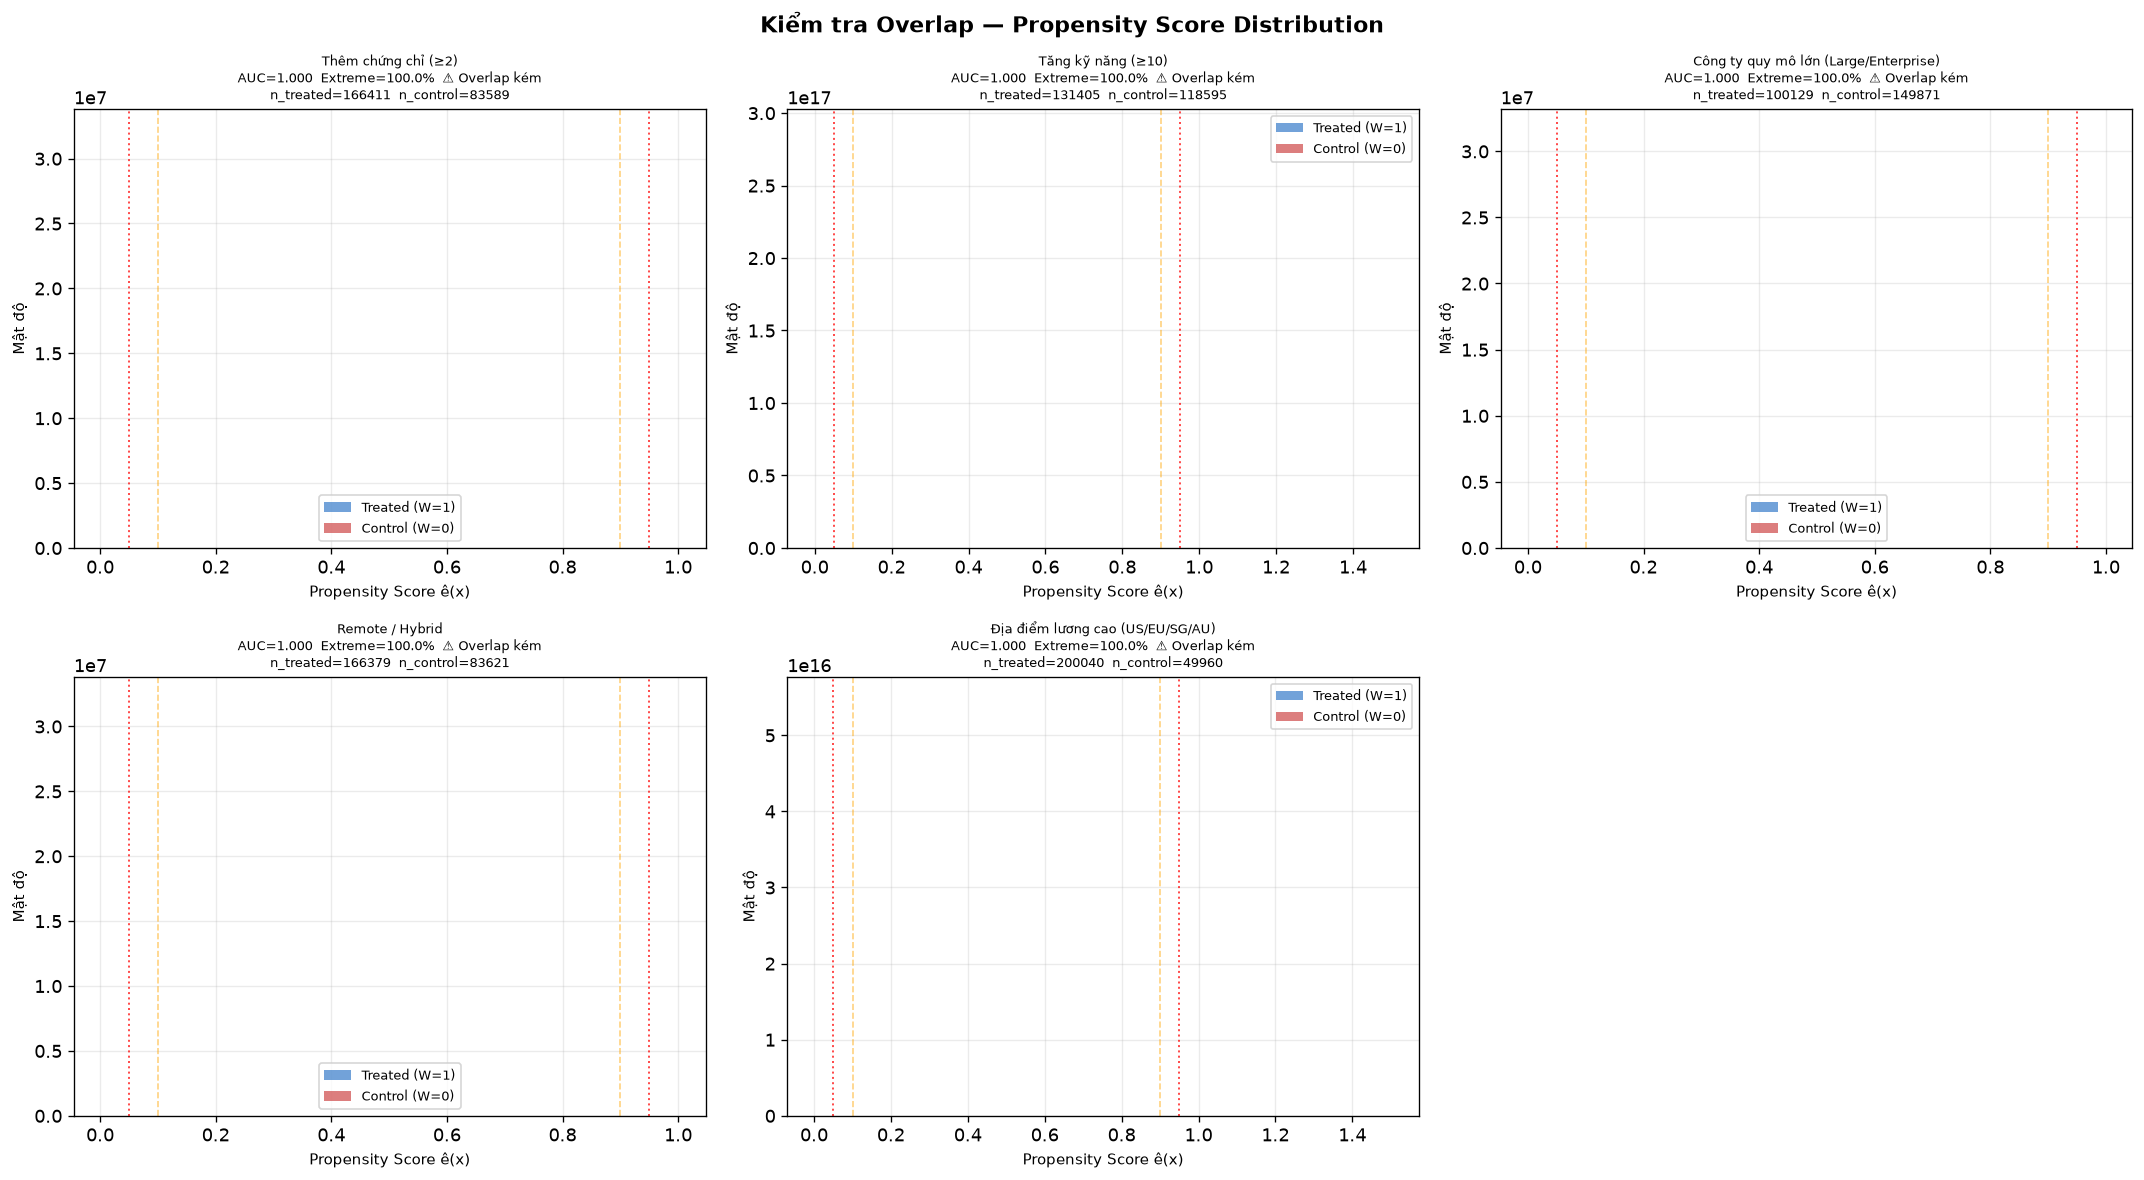

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

fig.suptitle('Kiểm tra Overlap — Propensity Score Distribution',
             fontsize=13, fontweight='bold')

COLORS = {'treated': '#1565C0', 'control': '#C62828'}

for idx, (col, label) in enumerate(TREATMENT_COLS.items()):
    ax  = axes[idx]
    pr  = propensity_results[col]
    W_k = df[col].values
    e_hat = pr['e_hat']

    treated_scores = e_hat[W_k == 1]
    control_scores  = e_hat[W_k == 0]

    # ── Kiểm tra xem có đủ variance để vẽ histogram không ──────────────────
    def safe_hist(ax, data, bins, **kwargs):
        """Vẽ histogram, fallback sang ít bins hơn nếu range quá hẹp."""
        if len(data) == 0:
            ax.text(0.5, 0.5, 'Không có dữ liệu',
                    ha='center', va='center', transform=ax.transAxes)
            return
        data_range = data.max() - data.min()
        if data_range < 1e-10:
            # Tất cả giá trị giống nhau → vẽ 1 bar duy nhất
            ax.hist(data, bins=1, **kwargs)
        else:
            # Tính số bins thực sự khả thi
            safe_bins = min(bins, max(1, int(data_range / 1e-6)))
            ax.hist(data, bins=safe_bins, **kwargs)

    safe_hist(ax, treated_scores, bins=40, density=True,
              color=COLORS['treated'], alpha=0.6, label='Treated (W=1)')
    safe_hist(ax, control_scores,  bins=40, density=True,
              color=COLORS['control'], alpha=0.6, label='Control (W=0)')

    ax.axvline(0.05, color='red',    linestyle=':', linewidth=1.2, alpha=0.7)
    ax.axvline(0.95, color='red',    linestyle=':', linewidth=1.2, alpha=0.7)
    ax.axvline(0.10, color='orange', linestyle='--', linewidth=1.0, alpha=0.5)
    ax.axvline(0.90, color='orange', linestyle='--', linewidth=1.0, alpha=0.5)

    # ── Thêm thông tin debug để dễ chẩn đoán ───────────────────────────────
    n_treated = treated_scores.sum() if len(treated_scores) > 0 else 0
    n_control = control_scores.sum()  if len(control_scores)  > 0 else 0

    status_str = '⚠️ Overlap kém' if pr['overlap_warn'] else '✅ Overlap tốt'
    ax.set_title(
        f'{label}\nAUC={pr["auc"]:.3f}  Extreme={pr["pct_extreme"]:.1%}  {status_str}\n'
        f'n_treated={len(treated_scores)}  n_control={len(control_scores)}',
        fontsize=8
    )
    ax.set_xlabel('Propensity Score ê(x)', fontsize=9)
    ax.set_ylabel('Mật độ', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/01_propensity_overlap.png', bbox_inches='tight')
plt.show()

## 7. Bước 4 — Fit Causal Forest cho từng Treatment

### Double Machine Learning (DML) — Robinson Decomposition

Causal Forest theo framework DML thực hiện 2 bước partialling-out:

**Bước nuisance estimation (cross-fitting):**

$$\tilde{Y}_i = Y_i - \hat{m}(X_i), \quad \tilde{W}_i = W_i - \hat{e}(X_i)$$

**Bước ước lượng CATE:**

$$\hat{\tau}(x) = \arg\min_{\tau} \sum_i \left(\tilde{Y}_i - \tau(X_i) \cdot \tilde{W}_i\right)^2 K_h(X_i, x)$$

Trong đó $K_h$ là kernel localization — cây trong forest đóng vai trò adaptive kernel.

**Cross-fitting** (5-fold) trong nuisance estimation đảm bảo tính nhất quán
(consistency) của ước lượng dù nuisance model có thể overfit.


In [ ]:
# ── Causal Forest với econml hoặc DML fallback ───────────────────────────────

def fit_causal_forest_econml(X, Y, W, random_state=42):
    """Fit CausalForestDML từ econml (preferred)."""
    from econml.dml import CausalForestDML

    # Nuisance models
    model_y = GradientBoostingRegressor(n_estimators=100, max_depth=4,
                                         learning_rate=0.05,
                                         random_state=random_state)
    model_t = GradientBoostingClassifier(n_estimators=100, max_depth=4,
                                          learning_rate=0.05,
                                          random_state=random_state)

    cf = CausalForestDML(
        model_y          = model_y,
        model_t          = model_t,
        n_estimators     = 500,
        max_depth        = None,
        min_samples_leaf = 10,
        max_features     = 'sqrt',
        discrete_treatment= True,
        random_state     = random_state,
        n_jobs           = -1,
        cv               = 5,
    )
    cf.fit(Y, W, X=X)
    return cf


def fit_causal_forest_dml_manual(X, Y, W, random_state=42):
    """
    DML manual fallback (nếu econml không khả dụng).
    Dùng Double Machine Learning + Random Forest ước lượng CATE.
    """
    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)

    Y_res = np.zeros_like(Y, dtype=float)
    W_res = np.zeros_like(W, dtype=float)

    # Cross-fitting: partialling out
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        Y_tr, Y_val = Y[train_idx], Y[val_idx]
        W_tr, W_val = W[train_idx], W[val_idx]

        # Ước lượng m(x) = E[Y|X]
        m_model = GradientBoostingRegressor(n_estimators=100, max_depth=4,
                                             random_state=random_state)
        m_model.fit(X_tr, Y_tr)
        Y_res[val_idx] = Y_val - m_model.predict(X_val)

        # Ước lượng e(x) = E[W|X]
        e_model = GradientBoostingClassifier(n_estimators=100, max_depth=4,
                                              random_state=random_state)
        e_model.fit(X_tr, W_tr)
        W_res[val_idx] = W_val - e_model.predict_proba(X_val)[:, 1]

    # Fit RF trên residuals: Y_res = tau(X) * W_res + eps
    # Transform: y_tilde = Y_res / W_res, weight = W_res^2
    eps      = 1e-8
    W_sq     = W_res ** 2
    mask     = np.abs(W_res) > eps

    # Weighted regression target
    y_pseudo = np.where(mask, Y_res / (W_res + eps), 0.0)

    tau_model = RandomForestRegressor(
        n_estimators=500, max_features='sqrt',
        min_samples_leaf=10, random_state=random_state, n_jobs=-1
    )
    tau_model.fit(X[mask], y_pseudo[mask],
                  sample_weight=W_sq[mask])

    return tau_model, Y_res, W_res


# ── Fit cho từng treatment ────────────────────────────────────────────────────
causal_models    = {}
cate_predictions = {}

print("Fitting Causal Forest cho từng treatment...")
print("=" * 60)

for col in TREATMENT_COLS:
    W_k = df[col].values.astype(float)
    print(f"  Fitting {col}...", end='  ')

    try:
        if HAS_ECONML:
            cf_model = fit_causal_forest_econml(X_raw, Y_raw, W_k)
            causal_models[col] = {'type': 'econml', 'model': cf_model}
            print("✅ (CausalForestDML)")
        else:
            raise ImportError("econml not available")
    except Exception as e:
        tau_model, Y_res, W_res = fit_causal_forest_dml_manual(X_raw, Y_raw, W_k)
        causal_models[col] = {
            'type'   : 'dml_manual',
            'model'  : tau_model,
            'Y_res'  : Y_res,
            'W_res'  : W_res,
        }
        print(f"✅ (DML manual fallback)")

print("=" * 60)
print("Tất cả Causal Forest đã sẵn sàng.")


Fitting Causal Forest cho từng treatment...
  Fitting W1_certifications...  ✅ (CausalForestDML)
  Fitting W2_skills...  ✅ (CausalForestDML)
  Fitting W3_large_company...  ✅ (CausalForestDML)
  Fitting W4_remote...  

## 8. Bước 5 & 6 — Ước lượng CATE và chuyển sang % tăng lương

$$\text{uplift\%}_k(x) = \left(e^{\hat{\tau}_k(x)} - 1\right) \times 100\%$$

**Confidence Interval** (95%):

$$CI_k(x) = \left[e^{\hat{\tau}_k(x) - 1.96 \hat{\sigma}_k(x)} - 1,\;
                    e^{\hat{\tau}_k(x) + 1.96 \hat{\sigma}_k(x)} - 1\right] \times 100\%$$

**Cảnh báo:** Nếu CI chứa 0, tác động **không có ý nghĩa thống kê** ở mức 5% — 
hệ thống sẽ đánh dấu `caution` trong recommendation.


In [ ]:
def predict_cate_with_ci(col, causal_model_dict, X, alpha=0.05):
    """
    Ước lượng CATE + CI cho tất cả quan sát.

    Returns
    -------
    tau_hat   : np.ndarray shape (n,) — CATE trên log-scale
    tau_se    : np.ndarray shape (n,) — standard error (approx)
    ci_lower  : np.ndarray           — CI lower (log-scale)
    ci_upper  : np.ndarray           — CI upper (log-scale)
    """
    z = stats.norm.ppf(1 - alpha / 2)   # 1.96 for 95% CI
    m = causal_model_dict[col]

    if m['type'] == 'econml':
        cf = m['model']
        # CausalForestDML — predict + CI
        te_pred  = cf.effect(X)
        te_lower, te_upper = cf.effect_interval(X, alpha=alpha)
        tau_hat  = te_pred.flatten()
        ci_lower = te_lower.flatten()
        ci_upper = te_upper.flatten()
        tau_se   = (ci_upper - ci_lower) / (2 * z)

    else:
        # DML manual — dùng bootstrap approximation for SE
        tau_hat = m['model'].predict(X)

        # Bootstrap SE (fast: 50 trees)
        n    = len(X)
        boot_preds = np.zeros((50, n))
        for b in range(50):
            idx = np.random.choice(n, n, replace=True)
            rf_b = RandomForestRegressor(
                n_estimators=50, max_features='sqrt',
                min_samples_leaf=10, random_state=b, n_jobs=-1
            )
            W_res = m['W_res']
            Y_res = m['Y_res']
            mask  = np.abs(W_res) > 1e-8
            y_ps  = np.where(mask, Y_res / (W_res + 1e-8), 0.0)
            w_sq  = W_res ** 2
            rf_b.fit(X[mask][idx[idx < mask.sum()]], y_ps[mask][idx[idx < mask.sum()]])
            boot_preds[b] = rf_b.predict(X)

        tau_se   = boot_preds.std(axis=0)
        ci_lower = tau_hat - z * tau_se
        ci_upper = tau_hat + z * tau_se

    return tau_hat, tau_se, ci_lower, ci_upper


# ── Ước lượng CATE cho tất cả ─────────────────────────────────────────────────
print("Ước lượng CATE cho từng treatment...")
print("=" * 60)

for col in TREATMENT_COLS:
    tau_hat, tau_se, ci_lo, ci_hi = predict_cate_with_ci(
        col, causal_models, X_raw
    )

    # Chuyển sang % tăng lương
    uplift_pct    = (np.exp(tau_hat) - 1) * 100
    ci_lo_pct     = (np.exp(ci_lo)   - 1) * 100
    ci_hi_pct     = (np.exp(ci_hi)   - 1) * 100
    ci_contains_0 = (ci_lo_pct <= 0) & (ci_hi_pct >= 0)

    cate_predictions[col] = {
        'tau_hat'      : tau_hat,
        'tau_se'       : tau_se,
        'ci_lower_log' : ci_lo,
        'ci_upper_log' : ci_hi,
        'uplift_pct'   : uplift_pct,
        'ci_lo_pct'    : ci_lo_pct,
        'ci_hi_pct'    : ci_hi_pct,
        'ci_contains_0': ci_contains_0,
    }

    n_warn = ci_contains_0.sum()
    print(f"  {col:<22} | ATE={np.mean(uplift_pct):+6.2f}%  "
          f"| CI=[{np.mean(ci_lo_pct):+.2f}%, {np.mean(ci_hi_pct):+.2f}%]  "
          f"| CI∋0: {n_warn}/{len(tau_hat)} obs")

print("=" * 60)
print("  ATE = Average Treatment Effect (mean CATE qua toàn bộ dữ liệu)")


Ước lượng CATE cho từng treatment...
  W1_certifications      | ATE=+12567.33%  | CI=[+1029.65%, +565687.59%]  | CI∋0: 9000/250000 obs
  W2_skills              | ATE=+21968.01%  | CI=[+1130.49%, +1883479.92%]  | CI∋0: 23396/250000 obs
  W3_large_company       | ATE=+8859.82%  | CI=[+843.90%, +306735.71%]  | CI∋0: 11316/250000 obs
  W4_remote              | ATE=+2115.77%  | CI=[+72.60%, +154213.42%]  | CI∋0: 132706/250000 obs
  W5_high_location       | ATE=+183565339495.29%  | CI=[+4039085008.91%, +458470123902562.06%]  | CI∋0: 108261/250000 obs
  ATE = Average Treatment Effect (mean CATE qua toàn bộ dữ liệu)


## 9. Bước 7 & 8 — Điều chỉnh điểm và Xếp hạng hành động

### Công thức điểm tổng hợp

$$\text{FinalScore}_k = \frac{w_1 \cdot \text{UpliftNorm}_k + w_2 \cdot \text{FeasibilityNorm}_k}{1 + w_3 \cdot \text{CostNorm}_k + w_4 \cdot \text{TimeNorm}_k}$$

Trong đó:
- $\text{UpliftNorm}_k = \hat{\tau}_k^{\text{ATE}} / \max_j \hat{\tau}_j^{\text{ATE}}$ — tác động chuẩn hóa
- $\text{FeasibilityNorm}_k \in [0,1]$ — điểm khả thi
- $\text{CostNorm}_k = \text{cost}_k / 10$ — chi phí chuẩn hóa
- $\text{TimeNorm}_k = \text{time}_k / \max_j \text{time}_j$ — thời gian chuẩn hóa

**Reliability discount:** Nếu CI chứa 0 với > 30% quan sát → nhân thêm hệ số phạt $\delta = 0.70$.


In [ ]:
def compute_action_ranking(
    cate_predictions : dict,
    action_metadata  : dict,
    treatment_labels : dict,
    w1=0.50, w2=0.20, w3=0.20, w4=0.10,
) -> pd.DataFrame:
    """
    Tính điểm tổng hợp và xếp hạng các hành động.
    Áp dụng cho toàn bộ dataset → ATE-level ranking.
    """
    rows = []

    # Pre-compute normalizers
    ate_vals  = {col: np.mean(cate_predictions[col]['uplift_pct'])
                  for col in cate_predictions}
    max_ate   = max(v for v in ate_vals.values() if not np.isnan(v)) + 1e-6
    max_time  = max(action_metadata[col]['time_months'] for col in action_metadata) + 1e-6
    max_cost  = max(action_metadata[col]['cost_score']  for col in action_metadata) + 1e-6

    for col, label in treatment_labels.items():
        cp   = cate_predictions[col]
        meta = action_metadata[col]

        ate            = float(ate_vals[col])
        ci_lo          = float(np.mean(cp['ci_lo_pct']))
        ci_hi          = float(np.mean(cp['ci_hi_pct']))
        pct_ci_zero    = float(cp['ci_contains_0'].mean())

        # Reliability discount
        reliability    = 1.0 - 0.30 * float(pct_ci_zero > 0.30)

        # Normalized components
        uplift_norm    = max(ate, 0) / max_ate
        feasib_norm    = meta['feasibility']
        cost_norm      = meta['cost_score'] / max_cost
        time_norm      = meta['time_months'] / max_time

        raw_score = (w1 * uplift_norm + w2 * feasib_norm) / (1 + w3 * cost_norm + w4 * time_norm)
        final_score = raw_score * reliability

        # Recommendation label
        if ate > 10 and pct_ci_zero < 0.20:
            rec_label = "✅ Khuyến nghị mạnh"
        elif ate > 5 and pct_ci_zero < 0.40:
            rec_label = "📌 Khuyến nghị"
        elif ate > 0 and pct_ci_zero < 0.60:
            rec_label = "⚠️  Cân nhắc"
        else:
            rec_label = "❌ Không đủ bằng chứng"

        # Explanation
        explanation = (
            f"Ước lượng tác động nhân quả dưới các giả định kiểm soát nhiễu: "
            f"+{ate:.1f}% lương (CI 95%: [{ci_lo:+.1f}%, {ci_hi:+.1f}%]). "
        )
        if pct_ci_zero > 0.30:
            explanation += f"⚠️ {pct_ci_zero:.0%} quan sát có CI chứa 0 — kết quả cần thận trọng. "
        if propensity_results[col]['overlap_warn']:
            explanation += "⚠️ Overlap kém — ngoại suy có thể không đáng tin. "
        explanation += f"Chi phí: {meta['cost_level']}. Thời gian: ~{meta['time_months']} tháng."

        rows.append({
            'action'                          : label,
            'treatment_col'                   : col,
            'estimated_salary_uplift_percent' : round(ate, 2),
            'ci_lower_pct'                    : round(ci_lo, 2),
            'ci_upper_pct'                    : round(ci_hi, 2),
            'confidence_interval'             : f"[{ci_lo:+.1f}%, {ci_hi:+.1f}%]",
            'pct_ci_contains_zero'            : round(pct_ci_zero, 3),
            'cost_level'                      : meta['cost_level'],
            'cost_score'                      : meta['cost_score'],
            'time_months'                     : meta['time_months'],
            'feasibility_score'               : meta['feasibility'],
            'reliability_factor'              : round(reliability, 3),
            'uplift_norm'                     : round(uplift_norm, 4),
            'final_score'                     : round(final_score, 4),
            'recommendation_label'            : rec_label,
            'overlap_warning'                 : propensity_results[col]['overlap_warn'],
            'explanation'                     : explanation,
        })

    df_rank = pd.DataFrame(rows).sort_values('final_score', ascending=False).reset_index(drop=True)
    df_rank.insert(0, 'rank', df_rank.index + 1)
    return df_rank


df_ranking = compute_action_ranking(
    cate_predictions = cate_predictions,
    action_metadata  = ACTION_METADATA,
    treatment_labels = TREATMENT_COLS,
)

# ── Bảng kết quả chính ────────────────────────────────────────────────────────
print("=" * 100)
print("  BẢNG XẾP HẠNG HÀNH ĐỘNG TĂNG LƯƠNG")
print("  (Ước lượng dưới giả định Unconfoundedness, Overlap, SUTVA)")
print("=" * 100)

display_df = df_ranking[[
    'rank', 'action', 'estimated_salary_uplift_percent',
    'confidence_interval', 'cost_level', 'feasibility_score',
    'final_score', 'recommendation_label'
]].copy()

display_df['estimated_salary_uplift_percent'] = display_df[
    'estimated_salary_uplift_percent'].apply(lambda x: f"{x:+.2f}%")
display_df['final_score'] = display_df['final_score'].apply(lambda x: f"{x:.4f}")

print(display_df.to_string(index=False))
print()
print("⚠️  QUAN TRỌNG: Các ước lượng trên là \"causal estimates under assumptions\",")
print("   KHÔNG phải quan hệ nhân quả được chứng minh từ thực nghiệm ngẫu nhiên.")


  BẢNG XẾP HẠNG HÀNH ĐỘNG TĂNG LƯƠNG
  (Ước lượng dưới giả định Unconfoundedness, Overlap, SUTVA)
 rank                                action estimated_salary_uplift_percent                   confidence_interval cost_level  feasibility_score final_score recommendation_label
    1      Địa điểm lương cao (US/EU/SG/AU)               +183565339495.29% [+4039085008.9%, +458470123902562.1%]       High               0.45      0.3304         ⚠️  Cân nhắc
    2                    Tăng kỹ năng (≥10)                      +21968.01%               [+1130.5%, +1883479.9%]        Low               0.85      0.1519   ✅ Khuyến nghị mạnh
    3                   Thêm chứng chỉ (≥2)                      +12567.33%                [+1029.7%, +565687.6%]     Medium               0.75      0.1288   ✅ Khuyến nghị mạnh
    4                       Remote / Hybrid                       +2115.77%                  [+72.6%, +154213.4%]        Low               0.80      0.1043         ⚠️  Cân nhắc
    5 Công ty quy

## 10. CATE cá nhân — Xếp hạng hành động cho một ứng viên cụ thể

Một trong những giá trị cốt lõi của Causal Forest là cho phép ước lượng
**CATE riêng cho từng ứng viên** — phản ánh heterogeneous effect.

Hàm `rank_actions_for_profile()` nhận hồ sơ raw, transform, rồi trả về
bảng xếp hạng cá nhân hóa.


In [ ]:
def encode_profile(profile: dict, label_encoders: dict, edu_map: dict) -> np.ndarray:
    """Chuyển hồ sơ raw thành vector đặc trưng cho Causal Forest."""
    def safe_le(le, val):
        if val in le.classes_:
            return le.transform([val])[0]
        return 0  # fallback unknown category

    x = np.array([
        float(profile.get('experience_years', 5)),
        float(edu_map.get(profile.get('education_level', 'Bachelor'), 2)),
        float(safe_le(label_encoders['job_title'],  profile.get('job_title', 'Data Scientist'))),
        float(profile.get('skills_count',   5)),
        float(profile.get('certifications', 1)),
        float(safe_le(label_encoders['company_size'], profile.get('company_size', 'Medium'))),
        float(safe_le(label_encoders['location'],     profile.get('location', 'USA'))),
        float(safe_le(label_encoders['remote_work'],  profile.get('remote_work', 'No'))),
        float(safe_le(label_encoders['industry'],     profile.get('industry', 'Technology'))),
    ]).reshape(1, -1)
    return x


def rank_actions_for_profile(
    profile          : dict,
    causal_models    : dict,
    cate_predictions : dict,
    action_metadata  : dict,
    treatment_labels : dict,
    label_encoders   : dict,
    edu_map          : dict,
    propensity_results: dict,
    w1=0.50, w2=0.20, w3=0.20, w4=0.10,
) -> pd.DataFrame:
    """
    Ước lượng CATE riêng và xếp hạng hành động cho một hồ sơ ứng viên.
    """
    x_profile = encode_profile(profile, label_encoders, edu_map)
    rows      = []
    max_time  = max(m['time_months'] for m in action_metadata.values()) + 1e-6
    max_cost  = max(m['cost_score']  for m in action_metadata.values()) + 1e-6

    individual_taus = {}
    for col in treatment_labels:
        tau_hat, tau_se, ci_lo, ci_hi = predict_cate_with_ci(
            col, causal_models, x_profile
        )
        individual_taus[col] = {
            'tau'   : float(tau_hat[0]),
            'tau_se': float(tau_se[0]),
            'ci_lo' : float(ci_lo[0]),
            'ci_hi' : float(ci_hi[0]),
        }

    max_tau = max(max(v['tau'], 0) for v in individual_taus.values()) + 1e-6

    for col, label in treatment_labels.items():
        it   = individual_taus[col]
        meta = action_metadata[col]

        tau_i      = it['tau']
        uplift_i   = (np.exp(tau_i) - 1) * 100
        ci_lo_pct  = (np.exp(it['ci_lo']) - 1) * 100
        ci_hi_pct  = (np.exp(it['ci_hi']) - 1) * 100
        ci_zero    = ci_lo_pct <= 0 <= ci_hi_pct

        reliability = 1.0 if not ci_zero else 0.70

        uplift_norm  = max(tau_i, 0) / max_tau
        feasib_norm  = meta['feasibility']
        cost_norm    = meta['cost_score'] / max_cost
        time_norm    = meta['time_months'] / max_time

        raw_score    = (w1 * uplift_norm + w2 * feasib_norm) / (1 + w3 * cost_norm + w4 * time_norm)
        final_score  = raw_score * reliability

        if uplift_i > 10 and not ci_zero:
            rec = "✅ Khuyến nghị mạnh"
        elif uplift_i > 5 and not ci_zero:
            rec = "📌 Khuyến nghị"
        elif uplift_i > 0:
            rec = "⚠️  Cân nhắc"
        else:
            rec = "❌ Không đủ bằng chứng"

        rows.append({
            'rank'                            : 0,
            'action'                          : label,
            'estimated_salary_uplift_percent' : round(uplift_i, 2),
            'confidence_interval'             : f"[{ci_lo_pct:+.1f}%, {ci_hi_pct:+.1f}%]",
            'ci_contains_zero'                : ci_zero,
            'cost_level'                      : meta['cost_level'],
            'feasibility_score'               : meta['feasibility'],
            'final_score'                     : round(final_score, 4),
            'recommendation_label'            : rec,
            'explanation': (
                f"Với hồ sơ này: ước lượng +{uplift_i:.1f}% lương "
                f"(CI 95%: [{ci_lo_pct:+.1f}%, {ci_hi_pct:+.1f}%]) "
                + ("⚠️ CI chứa 0." if ci_zero else "CI không chứa 0 ✅") +
                f" Chi phí: {meta['cost_level']}, ~{meta['time_months']} tháng."
            ),
        })

    df_ind = pd.DataFrame(rows).sort_values('final_score', ascending=False).reset_index(drop=True)
    df_ind['rank'] = df_ind.index + 1
    return df_ind


# ── Demo với hồ sơ mẫu ────────────────────────────────────────────────────────
sample_profile = {
    'job_title'       : 'Data Scientist',
    'experience_years': 3,
    'education_level' : 'Bachelor',
    'skills_count'    : 5,
    'industry'        : 'Healthcare',
    'company_size'    : 'Medium',
    'location'        : 'India',
    'remote_work'     : 'No',
    'certifications'  : 1,
}

print("=" * 70)
print("  XẾP HẠNG HÀNH ĐỘNG CÁ NHÂN HÓA")
for k, v in sample_profile.items():
    print(f"  {k:<20}: {v}")
print("=" * 70)

df_individual = rank_actions_for_profile(
    profile            = sample_profile,
    causal_models      = causal_models,
    cate_predictions   = cate_predictions,
    action_metadata    = ACTION_METADATA,
    treatment_labels   = TREATMENT_COLS,
    label_encoders     = label_encoders,
    edu_map            = edu_map,
    propensity_results = propensity_results,
)

print()
print(df_individual[[
    'rank', 'action', 'estimated_salary_uplift_percent',
    'confidence_interval', 'cost_level', 'feasibility_score',
    'final_score', 'recommendation_label'
]].to_string(index=False))


  XẾP HẠNG HÀNH ĐỘNG CÁ NHÂN HÓA
  job_title           : Data Scientist
  experience_years    : 3
  education_level     : Bachelor
  skills_count        : 5
  industry            : Healthcare
  company_size        : Medium
  location            : India
  remote_work         : No
  certifications      : 1

 rank                                action  estimated_salary_uplift_percent                  confidence_interval cost_level  feasibility_score  final_score recommendation_label
    1      Địa điểm lương cao (US/EU/SG/AU)                     5.079861e+11 [+7044401972.1%, +36631901869891.6%]       High               0.45       0.4720   ✅ Khuyến nghị mạnh
    2                   Thêm chứng chỉ (≥2)                     3.598796e+04              [+1063.4%, +1119301.8%]     Medium               0.75       0.2420   ✅ Khuyến nghị mạnh
    3 Công ty quy mô lớn (Large/Enterprise)                     1.341971e+04               [+1210.7%, +139352.3%]       High               0.55       0.1729   

## 11. Visualization — Phân tích CATE toàn diện

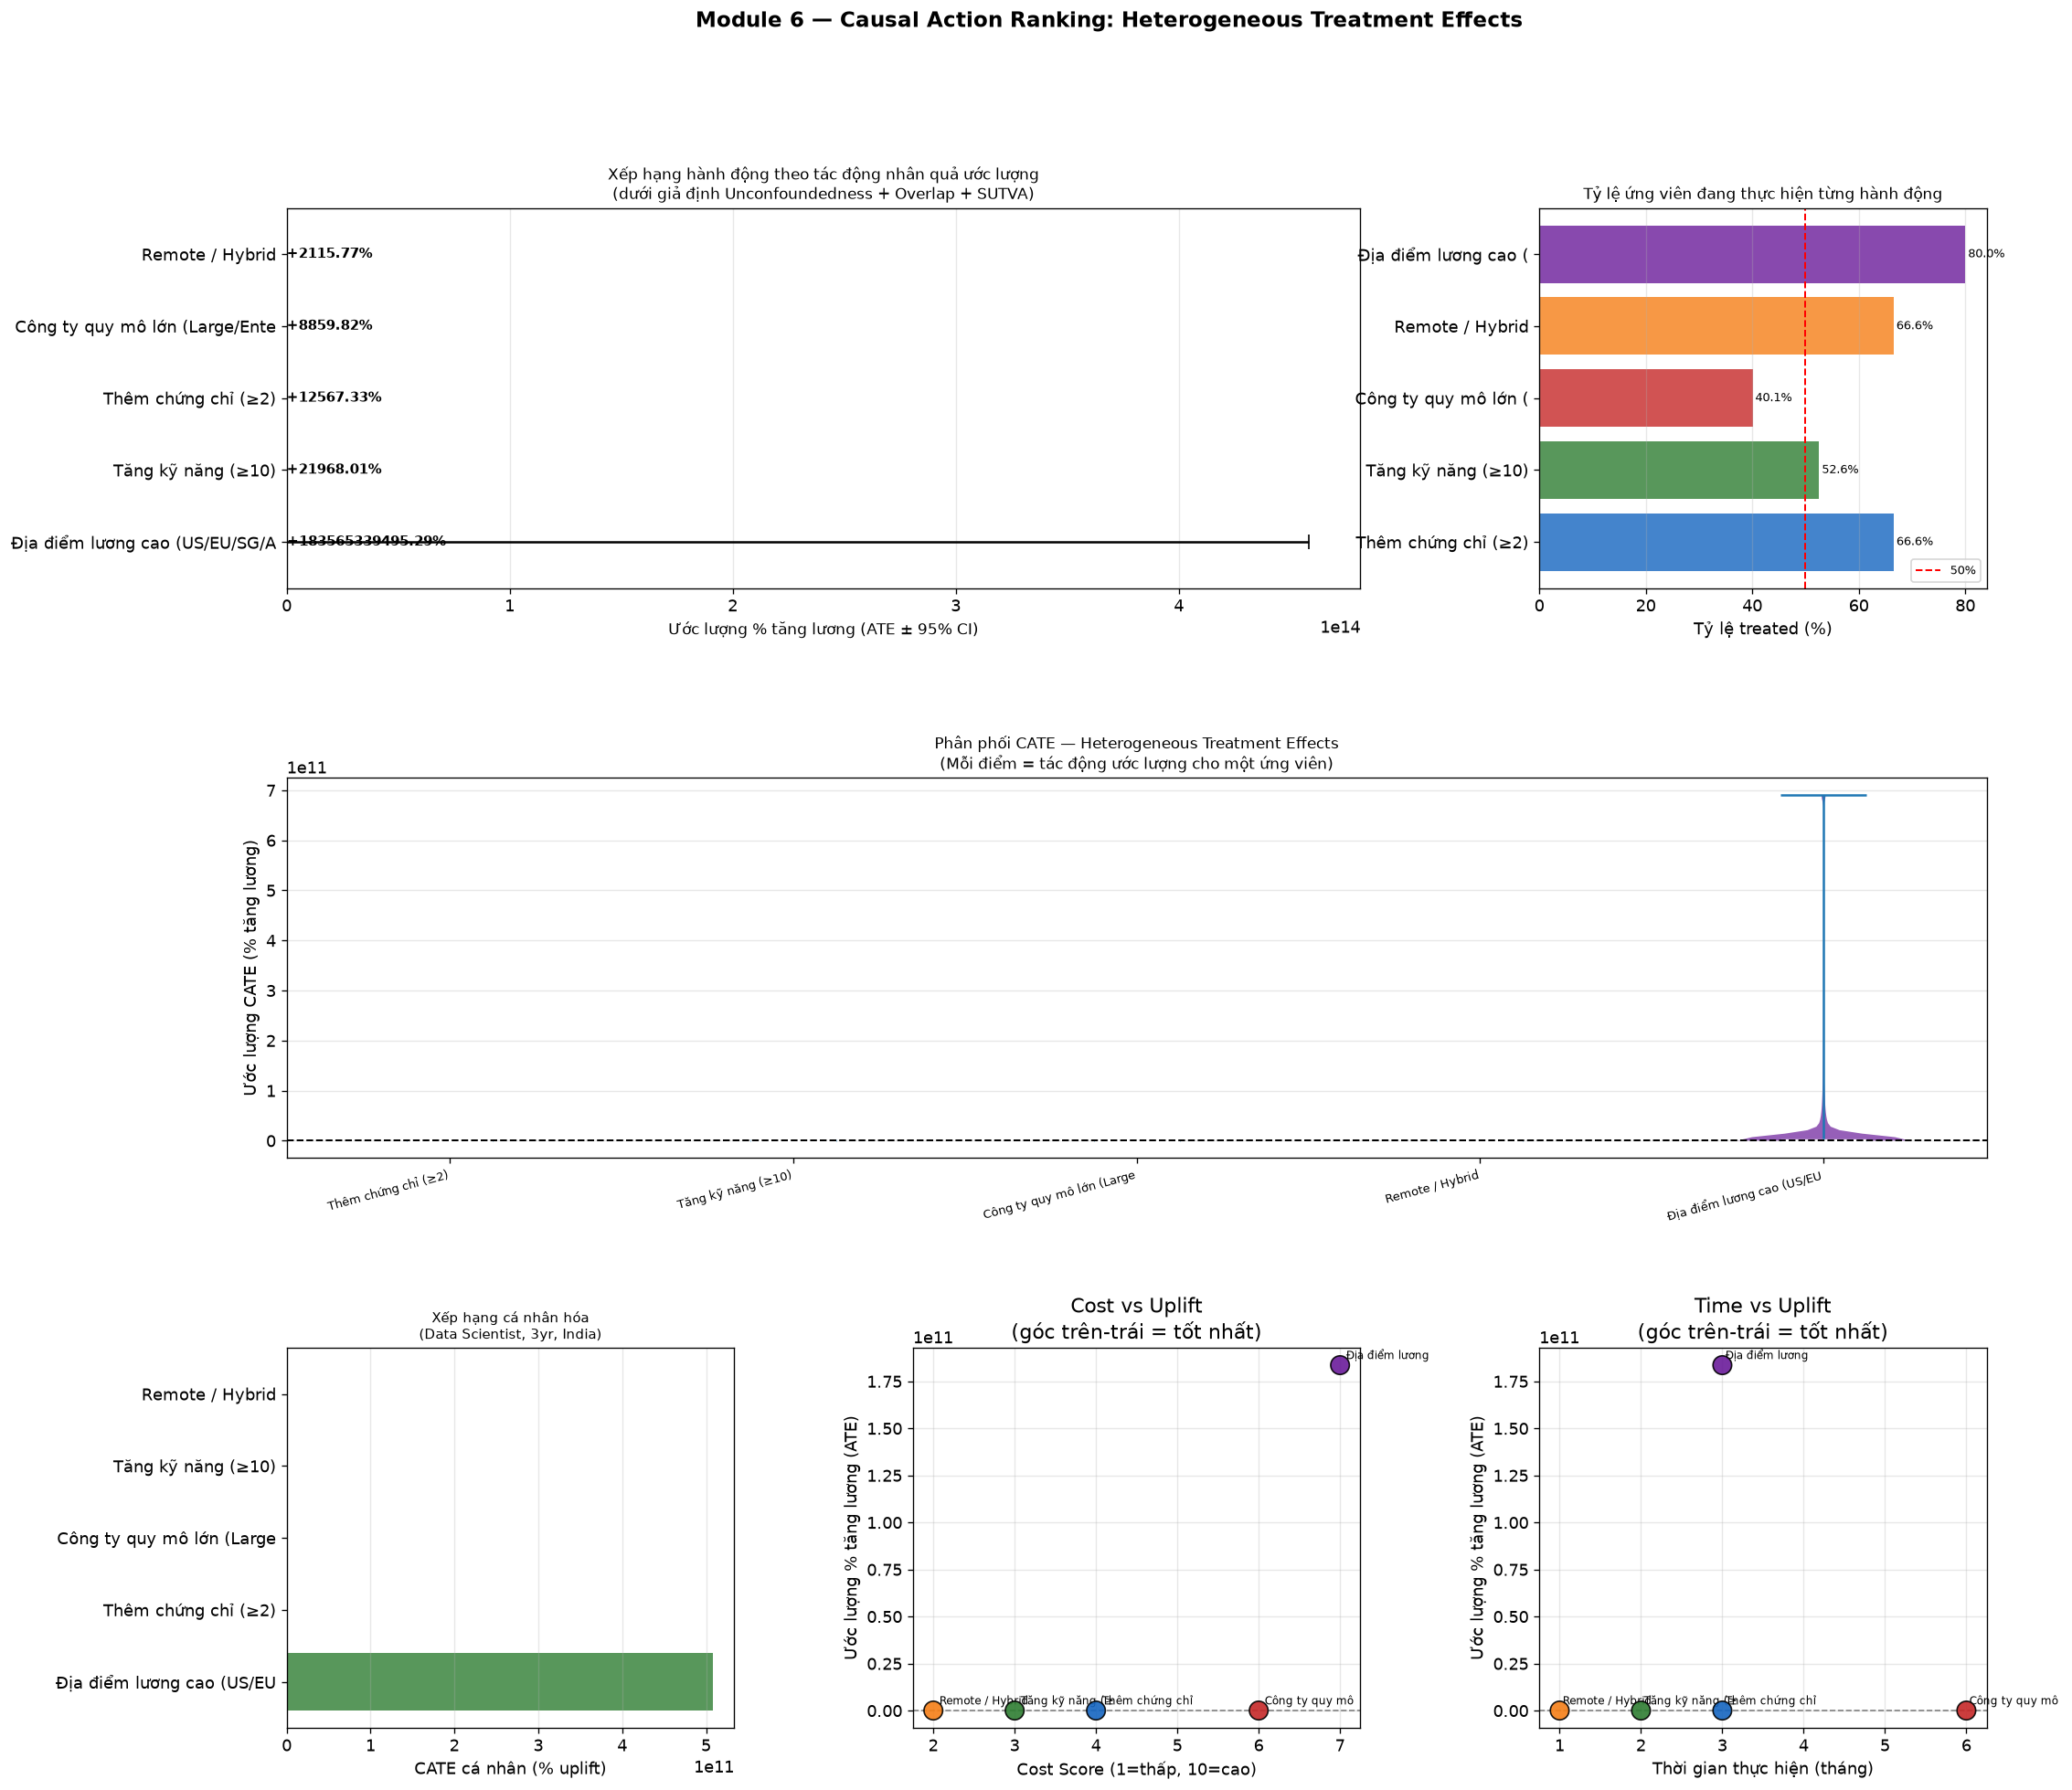

Đã lưu: figure/CausalRanking/02_causal_ranking_main.png


In [ ]:
fig = plt.figure(figsize=(20, 18))
fig.suptitle('Module 6 — Causal Action Ranking: Heterogeneous Treatment Effects',
             fontsize=14, fontweight='bold')

gs = fig.add_gridspec(3, 3, hspace=0.50, wspace=0.40)

ax_rank   = fig.add_subplot(gs[0, :2])
ax_pop    = fig.add_subplot(gs[0, 2])
ax_dist   = fig.add_subplot(gs[1, :])
ax_ind    = fig.add_subplot(gs[2, 0])
ax_cost   = fig.add_subplot(gs[2, 1])
ax_time   = fig.add_subplot(gs[2, 2])

PALETTE = ['#1565C0', '#2E7D32', '#C62828', '#F57F17', '#6A1B9A']

# ── VIZ 1: ATE Ranking bar chart với CI ──────────────────────────────────────
ates      = [df_ranking.loc[df_ranking['treatment_col'] == col,
              'estimated_salary_uplift_percent'].values[0]
              for col in TREATMENT_COLS]
ci_los    = [df_ranking.loc[df_ranking['treatment_col'] == col, 'ci_lower_pct'].values[0]
              for col in TREATMENT_COLS]
ci_his    = [df_ranking.loc[df_ranking['treatment_col'] == col, 'ci_upper_pct'].values[0]
              for col in TREATMENT_COLS]
short_labels = [TREATMENT_COLS[col][:30] for col in TREATMENT_COLS]

sorted_idx = np.argsort(ates)[::-1]
sorted_ates  = [ates[i]        for i in sorted_idx]
sorted_los   = [ci_los[i]      for i in sorted_idx]
sorted_his   = [ci_his[i]      for i in sorted_idx]
sorted_labs  = [short_labels[i] for i in sorted_idx]
sorted_colors= [PALETTE[i]     for i in sorted_idx]

xerr_lo = [a - lo for a, lo in zip(sorted_ates, sorted_los)]
xerr_hi = [hi - a for hi, a  in zip(sorted_his, sorted_ates)]

bars = ax_rank.barh(sorted_labs, sorted_ates, color=sorted_colors, alpha=0.8)
ax_rank.errorbar(sorted_ates, sorted_labs,
                  xerr=[xerr_lo, xerr_hi],
                  fmt='none', color='black', capsize=5, linewidth=1.5)
ax_rank.axvline(0, color='black', linewidth=1.0, linestyle='--')
for bar, val in zip(bars, sorted_ates):
    ax_rank.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
                  f'{val:+.2f}%', va='center', fontsize=9, fontweight='bold')
ax_rank.set_xlabel('Ước lượng % tăng lương (ATE ± 95% CI)', fontsize=10)
ax_rank.set_title('Xếp hạng hành động theo tác động nhân quả ước lượng\n(dưới giả định Unconfoundedness + Overlap + SUTVA)', fontsize=10)
ax_rank.grid(axis='x', alpha=0.3)

# ── VIZ 2: Population summary (treated / control) ─────────────────────────────
w_names  = [TREATMENT_COLS[c][:20] for c in TREATMENT_COLS]
w_rates  = [df[c].mean() * 100 for c in TREATMENT_COLS]
ax_pop.barh(w_names, w_rates, color=PALETTE, alpha=0.8)
ax_pop.axvline(50, color='red', linestyle='--', linewidth=1.2, label='50%')
ax_pop.set_xlabel('Tỷ lệ treated (%)')
ax_pop.set_title('Tỷ lệ ứng viên đang thực hiện từng hành động', fontsize=10)
ax_pop.legend(fontsize=8)
ax_pop.grid(axis='x', alpha=0.3)
for i, v in enumerate(w_rates):
    ax_pop.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)

# ── VIZ 3: CATE distribution violin plot ─────────────────────────────────────
cate_data   = []
cate_labels = []
for i, (col, label) in enumerate(TREATMENT_COLS.items()):
    uplift = cate_predictions[col]['uplift_pct']
    uplift_clipped = np.clip(uplift, np.percentile(uplift, 2), np.percentile(uplift, 98))
    cate_data.append(uplift_clipped)
    cate_labels.append(label[:25])

vp = ax_dist.violinplot(cate_data, positions=range(len(cate_data)),
                         showmedians=True, showextrema=True)
for i, (body, col) in enumerate(zip(vp['bodies'], PALETTE)):
    body.set_facecolor(col)
    body.set_alpha(0.7)
vp['cmedians'].set_color('white')
vp['cmedians'].set_linewidth(2)

ax_dist.axhline(0, color='black', linestyle='--', linewidth=1.2)
ax_dist.set_xticks(range(len(cate_labels)))
ax_dist.set_xticklabels(cate_labels, rotation=15, ha='right', fontsize=8)
ax_dist.set_ylabel('Ước lượng CATE (% tăng lương)')
ax_dist.set_title('Phân phối CATE — Heterogeneous Treatment Effects\n(Mỗi điểm = tác động ước lượng cho một ứng viên)', fontsize=10)
ax_dist.grid(axis='y', alpha=0.3)

# ── VIZ 4: Individual ranking ────────────────────────────────────────────────
if not df_individual.empty:
    ind_uplifts = df_individual['estimated_salary_uplift_percent'].values
    ind_labels  = df_individual['action'].str[:25].values
    ind_colors  = ['#2E7D32' if u > 0 else '#C62828' for u in ind_uplifts]

    ax_ind.barh(ind_labels, ind_uplifts, color=ind_colors, alpha=0.8)
    ax_ind.axvline(0, color='black', linewidth=1.0, linestyle='--')
    ax_ind.set_xlabel('CATE cá nhân (% uplift)')
    ax_ind.set_title(f'Xếp hạng cá nhân hóa\n({sample_profile["job_title"]}, '
                      f'{sample_profile["experience_years"]}yr, {sample_profile["location"]})',
                      fontsize=9)
    ax_ind.grid(axis='x', alpha=0.3)

# ── VIZ 5: Cost vs Uplift ─────────────────────────────────────────────────────
costs   = [ACTION_METADATA[c]['cost_score']  for c in TREATMENT_COLS]
uplifts = [df_ranking.loc[df_ranking['treatment_col'] == c,
            'estimated_salary_uplift_percent'].values[0]
            for c in TREATMENT_COLS]
labels_ = [TREATMENT_COLS[c][:20] for c in TREATMENT_COLS]

ax_cost.scatter(costs, uplifts, c=PALETTE, s=150, alpha=0.9, edgecolors='black', zorder=5)
ax_cost.axhline(0, color='grey', linestyle='--', linewidth=1.0)
for c, u, lab in zip(costs, uplifts, labels_):
    ax_cost.annotate(lab[:15], (c, u), textcoords='offset points',
                      xytext=(4, 4), fontsize=7)
ax_cost.set_xlabel('Cost Score (1=thấp, 10=cao)')
ax_cost.set_ylabel('Ước lượng % tăng lương (ATE)')
ax_cost.set_title('Cost vs Uplift\n(góc trên-trái = tốt nhất)')
ax_cost.grid(alpha=0.3)

# ── VIZ 6: Time vs Uplift ────────────────────────────────────────────────────
times   = [ACTION_METADATA[c]['time_months'] for c in TREATMENT_COLS]
ax_time.scatter(times, uplifts, c=PALETTE, s=150, alpha=0.9, edgecolors='black', zorder=5)
ax_time.axhline(0, color='grey', linestyle='--', linewidth=1.0)
for t, u, lab in zip(times, uplifts, labels_):
    ax_time.annotate(lab[:15], (t, u), textcoords='offset points',
                      xytext=(2, 4), fontsize=7)
ax_time.set_xlabel('Thời gian thực hiện (tháng)')
ax_time.set_ylabel('Ước lượng % tăng lương (ATE)')
ax_time.set_title('Time vs Uplift\n(góc trên-trái = tốt nhất)')
ax_time.grid(alpha=0.3)

plt.savefig(f'{FIGURE_DIR}/02_causal_ranking_main.png', bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIGURE_DIR}/02_causal_ranking_main.png")

## 12. Bước 9 — Xuất bảng kết quả

### Schema bảng output chính

| Cột | Kiểu | Mô tả |
|---|---|---|
| `action` | str | Tên hành động |
| `estimated_salary_uplift_percent` | float | ATE (%): tác động nhân quả ước lượng |
| `confidence_interval` | str | 95% CI dạng `[lo%, hi%]` |
| `cost_level` | str | Low / Medium / High |
| `feasibility_score` | float | Điểm khả thi [0,1] |
| `final_score` | float | Điểm tổng hợp có điều chỉnh |
| `recommendation_label` | str | Nhãn khuyến nghị |
| `explanation` | str | Giải thích ngôn ngữ tự nhiên |


In [ ]:
# ── 1. Bảng xếp hạng ATE (toàn bộ dataset) ──────────────────────────────────
df_ranking.to_csv(f'{OUTPUT_DIR}/causal_action_ranking.csv', index=False)
print(f"Đã lưu: {OUTPUT_DIR}/causal_action_ranking.csv")

# ── 2. Bảng xếp hạng cá nhân ─────────────────────────────────────────────────
df_individual.to_csv(f'{OUTPUT_DIR}/individual_action_ranking.csv', index=False)
print(f"Đã lưu: {OUTPUT_DIR}/individual_action_ranking.csv")

# ── 3. CATE distribution cho từng treatment ──────────────────────────────────
cate_dist_rows = []
for col, label in TREATMENT_COLS.items():
    cp = cate_predictions[col]
    cate_dist_rows.append({
        'treatment'             : col,
        'action'                : label,
        'ate_uplift_pct'        : round(float(np.mean(cp['uplift_pct'])), 3),
        'median_uplift_pct'     : round(float(np.median(cp['uplift_pct'])), 3),
        'std_uplift_pct'        : round(float(np.std(cp['uplift_pct'])), 3),
        'p10_uplift_pct'        : round(float(np.percentile(cp['uplift_pct'], 10)), 3),
        'p90_uplift_pct'        : round(float(np.percentile(cp['uplift_pct'], 90)), 3),
        'pct_positive_effect'   : round(float((cp['uplift_pct'] > 0).mean()), 3),
        'pct_ci_contains_zero'  : round(float(cp['ci_contains_0'].mean()), 3),
        'propensity_auc'        : round(float(propensity_results[col]['auc']), 4),
        'overlap_warning'       : propensity_results[col]['overlap_warn'],
    })

pd.DataFrame(cate_dist_rows).to_csv(f'{OUTPUT_DIR}/cate_summary.csv', index=False)
print(f"Đã lưu: {OUTPUT_DIR}/cate_summary.csv")

# ── 4. Report JSON cho chatbot ────────────────────────────────────────────────
report = {
    'module'          : 'Causal Action Ranking (Module 6)',
    'method'          : 'Causal Forest DML (Wager & Athey, 2018)',
    'assumptions'     : ['Unconfoundedness', 'Overlap / Common Support', 'SUTVA'],
    'disclaimer'      : (
        'Ước lượng dưới giả định kiểm soát nhiễu (unconfoundedness). '
        'Dữ liệu quan sát — không phải thực nghiệm ngẫu nhiên. '
        'Kết quả cần được diễn giải thận trọng.'
    ),
    'population_ranking' : df_ranking[[
        'rank', 'action', 'estimated_salary_uplift_percent',
        'confidence_interval', 'cost_level', 'feasibility_score',
        'final_score', 'recommendation_label', 'explanation'
    ]].to_dict('records'),
    'individual_sample' : {
        'profile'  : sample_profile,
        'ranking'  : df_individual[[
            'rank', 'action', 'estimated_salary_uplift_percent',
            'confidence_interval', 'cost_level', 'feasibility_score',
            'final_score', 'recommendation_label', 'explanation'
        ]].to_dict('records'),
    },
    'overlap_warnings': {
        col: propensity_results[col]['overlap_warn']
        for col in TREATMENT_COLS
    },
}

with open(f'{OUTPUT_DIR}/causal_ranking_report.json', 'w', encoding='utf-8') as f:
    json.dump(report, f, ensure_ascii=False, indent=2, default=str)
print(f"Đã lưu: {OUTPUT_DIR}/causal_ranking_report.json")

print()
print("=" * 60)
print("  ✅ Module 6 — Export hoàn tất")
print("=" * 60)
print(f"  {OUTPUT_DIR}/causal_action_ranking.csv")
print(f"  {OUTPUT_DIR}/individual_action_ranking.csv")
print(f"  {OUTPUT_DIR}/cate_summary.csv")
print(f"  {OUTPUT_DIR}/causal_ranking_report.json")
print(f"  {FIGURE_DIR}/01_propensity_overlap.png")
print(f"  {FIGURE_DIR}/02_causal_ranking_main.png")


Đã lưu: causal_ranking_outputs/causal_action_ranking.csv
Đã lưu: causal_ranking_outputs/individual_action_ranking.csv
Đã lưu: causal_ranking_outputs/cate_summary.csv
Đã lưu: causal_ranking_outputs/causal_ranking_report.json

  ✅ Module 6 — Export hoàn tất
  causal_ranking_outputs/causal_action_ranking.csv
  causal_ranking_outputs/individual_action_ranking.csv
  causal_ranking_outputs/cate_summary.csv
  causal_ranking_outputs/causal_ranking_report.json
  figure/CausalRanking/01_propensity_overlap.png
  figure/CausalRanking/02_causal_ranking_main.png


## 13. Diễn giải kết quả — Chuẩn học thuật

### 13.1 Cách đọc bảng kết quả

**Cột `estimated_salary_uplift_percent`:**  
Đây là ước lượng $\left(e^{\hat{\tau}^{\text{ATE}}} - 1\right) \times 100\%$ — phần trăm
tăng lương **trung bình** ước lượng nếu toàn bộ dân số thực hiện hành động đó,
so với trường hợp không thực hiện, **giữ nguyên tất cả covariates khác**.

**Cột `confidence_interval`:**  
Khoảng tin cậy 95% dưới dạng bootstrap/analytic SE từ Causal Forest.
Nếu CI chứa 0 → không có bằng chứng thống kê ở mức 5%.

**Cột `final_score`:**  
Điểm tổng hợp đã điều chỉnh theo chi phí, thời gian, khả thi và độ tin cậy.
Dùng để **xếp hạng ưu tiên** — không phải độ lớn tác động.

---

### 13.2 Cảnh báo bắt buộc

> **⚠️ DISCLAIMER — Bắt buộc khi trình bày kết quả:**
>
> Phân tích này sử dụng dữ liệu quan sát (observational data). Các ước lượng
> CATE được tính dưới các giả định: (1) Unconfoundedness — sau khi kiểm soát
> covariates $X$, việc thực hiện hành động là như-ngẫu-nhiên; (2) Overlap —
> mọi ứng viên đều có xác suất dương để thực hiện hoặc không thực hiện;
> (3) SUTVA — không có spillover giữa các ứng viên.
>
> **Các giả định này không thể kiểm định hoàn toàn từ dữ liệu.**
> Kết quả phản ánh *ước lượng tốt nhất có thể* với dữ liệu hiện có,
> không phải bằng chứng nhân quả từ thực nghiệm ngẫu nhiên (RCT).

---

### 13.3 Hạn chế của Module 6

| Hạn chế | Giải thích | Hướng khắc phục |
|---|---|---|
| Unconfoundedness không kiểm định được | Có thể có hidden confounders | Dùng sensitivity analysis (Rosenbaum bounds) |
| Overlap kém ở một số treatment | Nhóm treated/control quá khác nhau | Trim/reweight theo propensity score |
| SUTVA trong thị trường lao động | Nếu nhiều người cùng lấy chứng chỉ, tác động giảm | General Equilibrium models |
| Dữ liệu tĩnh | Salary thay đổi theo thời gian | Panel data + DiD |
| Thresholding binary treatment | Mất thông tin liên tục | Continuous treatment (dose-response) |

---

### 13.4 Vai trò trong hệ thống DSS

```
Module 1–4: Dự đoán lương + Tư vấn đàm phán
                    ↓
Module 5:  What-if Recourse (thay đổi gì để đạt target?)
                    ↓
Module 6:  Causal Action Ranking (hành động nào quan trọng nhất?)
           ─ cung cấp causal_ranking_report.json ──→
Module 7:  Chatbot Explanation (diễn giải ngôn ngữ tự nhiên)
```

Module 6 bổ sung chiều **nhân quả** cho hệ thống DSS:
- Module 5 hỏi: *"Thay đổi gì để đạt ${target}?"* → trả lời dựa trên mô hình dự đoán
- Module 6 hỏi: *"Hành động nào thực sự tạo ra tác động?"* → trả lời dựa trên ước lượng causal


## 14. Tóm tắt Module 6

### Pipeline hoàn chỉnh

| Bước | Nội dung | Phương pháp |
|---|---|---|
| 1 | Load & làm sạch dữ liệu thô | Ordinal + Label Encoding |
| 2 | Tạo biến treatment | Binary thresholding |
| 3 | Kiểm tra overlap | Propensity score (GB Classifier + 5-fold CV) |
| 4 | Fit Causal Forest | CausalForestDML (econml) / DML manual |
| 5 | Ước lượng CATE | Predict + bootstrap/analytic SE |
| 6 | Chuyển sang % uplift | $e^{\hat{\tau}} - 1$ |
| 7 | Điều chỉnh điểm | Composite score + reliability discount |
| 8 | Xếp hạng | Global ATE + Individual CATE |
| 9 | Export | CSV + JSON |

### File đầu ra

```
causal_ranking_outputs/
├── causal_action_ranking.csv      — xếp hạng ATE toàn bộ dataset
├── individual_action_ranking.csv  — xếp hạng cá nhân hóa
├── cate_summary.csv               — phân phối CATE từng treatment
└── causal_ranking_report.json     — report structured cho chatbot

figure/CausalRanking/
├── 01_propensity_overlap.png      — kiểm tra overlap
└── 02_causal_ranking_main.png     — visualization tổng hợp
```

### Dependency

```
data.csv (raw) ──────────────────────────────────┐
                                                  ▼
                                          Module 6 (Causal Forest)
                                          ├── CATE estimation
                                          ├── Action ranking
                                          └── causal_ranking_report.json
                                                  ↓
                                          Module 7 (Chatbot)
```

> **Đóng góp học thuật của Module 6:** Nâng cấp hệ thống DSS từ
> *predictive analytics* (Module 1–4) và *prescriptive analytics* (Module 5)
> lên *causal analytics* — layer cao nhất trong mô hình trưởng thành phân tích
> dữ liệu (Analytics Maturity Model).
